<a href="https://colab.research.google.com/github/Ozonetom/Classifying-hot-subdwarf-stars-from-white-dwarfs/blob/main/StarClassification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Part 1: Downloading the first dataset**

In [ ]:
!wget --load-cookies /tmp/cookies.txt "https://docs.google.com/uc?export=download&confirm=$(wget --quiet --save-cookies /tmp/cookies.txt --keep-session-cookies --no-check-certificate 'https://docs.google.com/uc?export=download&id=1yCU6i7FPzQ9aSQ3Si85vYl2Zfij4zIHA' -O- | sed -rn 's/.*confirm=([0-9A-Za-z_]+).*/\1\n/p')&id=1yCU6i7FPzQ9aSQ3Si85vYl2Zfij4zIHA" -O dataset.csv && rm -rf /tmp/cookies.txt


--2025-06-16 08:24:53--  https://docs.google.com/uc?export=download&confirm=&id=1yCU6i7FPzQ9aSQ3Si85vYl2Zfij4zIHA
Resolving docs.google.com (docs.google.com)... 142.251.2.139, 142.251.2.113, 142.251.2.101, ...
Connecting to docs.google.com (docs.google.com)|142.251.2.139|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1yCU6i7FPzQ9aSQ3Si85vYl2Zfij4zIHA&export=download [following]
--2025-06-16 08:24:53--  https://drive.usercontent.google.com/download?id=1yCU6i7FPzQ9aSQ3Si85vYl2Zfij4zIHA&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 142.250.141.132, 2607:f8b0:4023:c0b::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|142.250.141.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 12703360 (12M) [application/octet-stream]
Saving to: ‘dataset.csv’

dataset.csv         100%[===================>]  12.11M  41.1MB/s 

# **Part 2: Importing pandas and read the dataset**
We want to analyze the head of the dataset and know how many White Dwarf and Subdwarf stars are within it

In [ ]:
# Imports
import pandas as pd

# Read dataset
df = pd.read_csv('dataset.csv')
print(df.head())

# Count the occurrences of each unique value in the 'class' column
class_counts = df['class'].value_counts()
class_counts


             source_id           l          b  parallax       pmra      pmdec  \
0  2414485448212792064   70.348195 -74.495269  0.358506   8.191703 -10.158815   
1  2773760665114010880  106.008961 -43.535733  0.309961   6.712501  -2.657927   
2  2847977322031768832  107.648750 -39.048785  1.179264   5.391933 -12.112534   
3  2313130542218587008    0.815691 -77.388132  0.366055  15.378720 -15.192124   
4  2765454164004531328  103.521407 -49.955490  1.614939  -3.893759 -11.751798   

   phot_g_mean_mag  phot_bp_mean_mag  phot_rp_mean_mag  ra_error  ...  \
0        16.769844         16.613232         17.088371  0.063354  ...   
1        16.519869         16.385021         16.806425  0.054034  ...   
2        14.219558         14.110446         14.426654  0.025606  ...   
3        16.474659         16.311130         16.792944  0.046254  ...   
4        13.589941         13.489800         13.777930  0.027977  ...   

   pmra_pmdec_corr  pmra_pseudocolour_corr  pseudocolour  pseudocolour_err

,count
class,
wd,13857
sdb,6593


# **Part 3: Creating the neural network**
We start by importing all necessary libraries, filter out invalid data and train a neural network model to make prediction.<br>

In [ ]:
# Imports (3.1)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow import keras
from tensorflow.keras import layers

# Filter the dataset to include only 'wd' and 'sdb' classes (3.2)
df_filtered = df[df['class'].isin(['wd', 'sdb'])]

# Separate features (X) and target variable (y) (3.3)
X = df_filtered.drop('class', axis=1)
y = df_filtered['class']

# Convert target variable to numerical values (0 for 'wd', 1 for 'sdb') (3.4)
y = y.map({'wd': 0, 'sdb': 1})

# Split the dataset into training and testing sets (3.5)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features (3.6)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Create a neural network model (3.7)
model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

# Compile the model (3.8)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

# Evaluate the model on the test set (3.9)
loss, accuracy = model.evaluate(X_test, y_test)
print('Test accuracy:', accuracy)

# Make predictions on the test set
y_pred = model.predict(X_test)
y_pred_classes = (y_pred > 0.5).astype(int)


Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


409/409 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6778 - loss: nan - val_accuracy: 0.6815 - val_loss: nan
Epoch 2/10
409/409 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6798 - loss: nan - val_accuracy: 0.6815 - val_loss: nan
Epoch 3/10
409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6763 - loss: nan - val_accuracy: 0.6815 - val_loss: nan
Epoch 4/10
409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6644 - loss: nan - val_accuracy: 0.6815 - val_loss: nan
Epoch 5/10
409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6750 - loss: nan - val_accuracy: 0.6815 - val_loss: nan
Epoch 6/10
409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6738 - loss: nan - val_accuracy: 0.6815 - val_loss: nan
Epoch 7/10
409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6746 - loss: nan - val_accuracy: 0.6815 - val_loss: nan
Epoch 8/10
409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6760 - loss: nan - val_accuracy: 0.6815 - val_loss: nan
Epoch 9/10
409/409 ━━━━━━━━━━━━━━━━

# **Part 4: Cleaning the data**
Here we do a first cleaning of the data. We will replace missing or invalid values for each feature with the mean average of that feature. <br>

In [ ]:
import pandas as pd

# Replace missing or invalid data with the mean value for each feature (except 'class')
for column in df.columns:
    if column != 'class':
        df[column] = pd.to_numeric(df[column], errors='coerce')  # Convert to numeric, handle non-numeric as NaN
        df[column].fillna(df[column].mean(), inplace=True)  # Replace NaN with mean

# Filter the dataset to include only 'wd' and 'sdb' classes
df_filtered = df[df['class'].isin(['wd', 'sdb'])]

# Separate features (X) and target variable (y)
X = df_filtered.drop('class', axis=1)
y = df_filtered['class']

# Convert target variable to numerical values (0 for 'wd', 1 for 'sdb')
y = y.map({'wd': 0, 'sdb': 1})

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Create a neural network model
model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

# Evaluate the model on the test set
loss, accuracy = model.evaluate(X_test, y_test)
print('Test accuracy:', accuracy)

# Make predictions on the test set
y_pred = model.predict(X_test)
y_pred_classes = (y_pred > 0.5).astype(int)


Epoch 1/10


<ipython-input-4-4242851940>:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[column].fillna(df[column].mean(), inplace=True)  # Replace NaN with mean
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


409/409 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9255 - loss: 0.2159 - val_accuracy: 0.9963 - val_loss: 0.0186
Epoch 2/10
409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9975 - loss: 0.0121 - val_accuracy: 0.9982 - val_loss: 0.0097
Epoch 3/10
409/409 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9986 - loss: 0.0047 - val_accuracy: 0.9991 - val_loss: 0.0078
Epoch 4/10
409/409 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9999 - loss: 0.0019 - val_accuracy: 0.9982 - val_loss: 0.0114
Epoch 5/10
409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9994 - loss: 0.0022 - val_accuracy: 0.9982 - val_loss: 0.0082
Epoch 6/10
409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9999 - loss: 8.0224e-04 - val_accuracy: 0.9991 - val_loss: 0.0074
Epoch 7/10
409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9992 - loss: 0.0029 - val_accuracy: 0.9985 - val_loss: 0.0101
Epoch 8/10
409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9984 - loss: 0.0048 - val_accuracy: 0.9988 - 

# **Part 5: Investigating the suspiciously perfect model**
A simple mean average data cleaning was enough to give us a nea 100% accuracy on our model. This is suspicious. We will separate the stars into 2 groups and train the model on one of them and test on the other. If the model is capable of such an accuracy again, then the accuracy is valid. <br>

In [ ]:
# Split the dataframe into two groups randomly
df_A, df_B = train_test_split(df, test_size=0.5, random_state=42)

# Count how many elements have either "wd" or "sdb" as value in their "class" feature for both groups
wd_sdb_count_A = df_A[df_A['class'].isin(['wd', 'sdb'])].shape[0]
wd_sdb_count_B = df_B[df_B['class'].isin(['wd', 'sdb'])].shape[0]

# Count how many of each "wd" and "sdb" are there in each group
wd_count_A = df_A[df_A['class'] == 'wd'].shape[0]
sdb_count_A = df_A[df_A['class'] == 'sdb'].shape[0]
wd_count_B = df_B[df_B['class'] == 'wd'].shape[0]
sdb_count_B = df_B[df_B['class'] == 'sdb'].shape[0]


print("Group A: Total elements with 'wd' or 'sdb' class:", wd_sdb_count_A)
print("Group A: Number of 'wd' elements:", wd_count_A)
print("Group A: Number of 'sdb' elements:", sdb_count_A)
print("-" * 20)
print("Group B: Total elements with 'wd' or 'sdb' class:", wd_sdb_count_B)
print("Group B: Number of 'wd' elements:", wd_count_B)
print("Group B: Number of 'sdb' elements:", sdb_count_B)


Group A: Total elements with 'wd' or 'sdb' class: 10225
Group A: Number of 'wd' elements: 6925
Group A: Number of 'sdb' elements: 3300
--------------------
Group B: Total elements with 'wd' or 'sdb' class: 10225
Group B: Number of 'wd' elements: 6932
Group B: Number of 'sdb' elements: 3293


In [ ]:
import pandas as pd
# Replace missing or invalid data with the mean value for each feature (except 'class')
for group_name, group_df in [('group_A', df_A), ('group_B', df_B)]:
  for column in group_df.columns:
      if column != 'class':
          group_df[column] = pd.to_numeric(group_df[column], errors='coerce')  # Convert to numeric, handle non-numeric as NaN
          group_df[column].fillna(group_df[column].mean(), inplace=True)  # Replace NaN with mean


<ipython-input-7-2189458563>:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  group_df[column].fillna(group_df[column].mean(), inplace=True)  # Replace NaN with mean


In [ ]:
# Filter the dataset to include only 'wd' and 'sdb' classes for group_A
df_filtered_A = df_A[df_A['class'].isin(['wd', 'sdb'])]

# Separate features (X) and target variable (y) for group_A
X_A = df_filtered_A.drop('class', axis=1)
y_A = df_filtered_A['class']

# Convert target variable to numerical values (0 for 'wd', 1 for 'sdb') for group_A
y_A = y_A.map({'wd': 0, 'sdb': 1})

# Scale the features for group_A
scaler_A = StandardScaler()
X_A = scaler_A.fit_transform(X_A)

# Create a neural network model
model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_A.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model on group_A
model.fit(X_A, y_A, epochs=10, batch_size=32, validation_split=0.2)

# Evaluate the model on group_A
loss_A, accuracy_A = model.evaluate(X_A, y_A)
print('Group A accuracy:', accuracy_A)

# Filter the dataset to include only 'wd' and 'sdb' classes for group_B
df_filtered_B = df_B[df_B['class'].isin(['wd', 'sdb'])]

# Separate features (X) and target variable (y) for group_B
X_B = df_filtered_B.drop('class', axis=1)
y_B = df_filtered_B['class']

# Convert target variable to numerical values (0 for 'wd', 1 for 'sdb') for group_B
y_B = y_B.map({'wd': 0, 'sdb': 1})

# Scale the features for group_B using the scaler fitted on group_A
X_B = scaler_A.transform(X_B)

# Evaluate the model on group_B
loss_B, accuracy_B = model.evaluate(X_B, y_B)
print('Group B accuracy:', accuracy_B)


Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


256/256 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.8872 - loss: 0.3226 - val_accuracy: 0.9883 - val_loss: 0.0494
Epoch 2/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9919 - loss: 0.0331 - val_accuracy: 0.9971 - val_loss: 0.0177
Epoch 3/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9975 - loss: 0.0100 - val_accuracy: 0.9980 - val_loss: 0.0128
Epoch 4/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9983 - loss: 0.0066 - val_accuracy: 0.9980 - val_loss: 0.0128
Epoch 5/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9998 - loss: 0.0024 - val_accuracy: 0.9985 - val_loss: 0.0124
Epoch 6/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9999 - loss: 0.0015 - val_accuracy: 0.9980 - val_loss: 0.0139
Epoch 7/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 1.0000 - loss: 9.6071e-04 - val_accuracy: 0.9980 - val_loss: 0.0132
Epoch 8/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 1.0000 - loss: 7.9251e-04 - val_accuracy: 0.99

# **Part 6: Investigating the feature correlation**
In part 5, we have ruled out the possibility of overfitting, because our model was capable of using the data of one group to make near perfect predictions on another. <br>
Another possibility to explain the suspiciously high accuracy is that perhaps one or more features are highly correlated with the "class" feature. If that is the case, then our model might use just these few features to make its predictions and not do any "real" work.<br>
In this part we will print the features with the highest correlations.

In [ ]:
import pandas as pd

# Copy and prepare the DataFrame
df_corr = df.copy()
df_corr['class'] = df_corr['class'].map({'wd': 0, 'sdb': 1})

# Convert all features to numeric, safely
for col in df_corr.columns:
    if col != 'class':
        df_corr[col] = pd.to_numeric(df_corr[col], errors='coerce')

# Drop rows with NaN values just for the correlation check
df_corr.dropna(inplace=True)

# Compute correlation matrix
corr_matrix = df_corr.corr()

# Get absolute correlation values with 'class', excluding 'class' itself
class_corr = corr_matrix['class'].drop('class').abs()

# Sort features by correlation strength
sorted_corr = class_corr.sort_values(ascending=False)

# Print top N most correlated features
top_n = 10
print(f"Top {top_n} features most correlated with 'class':")
print(sorted_corr.head(top_n))


Top 10 features most correlated with 'class':
phot_rp_mean_mag                0.702950
phot_bp_mean_mag                0.700175
phot_g_mean_mag                 0.686968
phot_bp_mean_flux_over_error    0.600906
parallax                        0.598912
phot_g_mean_flux_over_error     0.565074
phot_rp_mean_flux_over_error    0.516071
parallax_error                  0.449333
pmdec_error                     0.440797
pmra_error                      0.427160
Name: class, dtype: float64


# **Part 7: Re executing the neural network using only key features**
In part 6 we have identified 4 main key features that the neural network uses (the 3 magnitude features, and the parallax feature). <br>
To make our neural network 'cleaner', we will just use these 4 features as basis for our model and hopefully get a high enough accuracy.<br>


**Part 7.a: Rereading the dataset and dropping all unnecessary features**

In [ ]:
import pandas as pd

# Reread the dataset
df = pd.read_csv('dataset.csv')

# Select only the specified columns
selected_columns = ['source_id', 'phot_rp_mean_mag', 'phot_bp_mean_mag', 'phot_g_mean_mag', 'parallax', 'class']
df = df[selected_columns]

# Clean the data
for column in ['phot_rp_mean_mag', 'phot_bp_mean_mag', 'phot_g_mean_mag', 'parallax']:
    df[column] = pd.to_numeric(df[column], errors='coerce')
    df[column].fillna(df[column].mean(), inplace=True)

print(df.head())


             source_id  phot_rp_mean_mag  phot_bp_mean_mag  phot_g_mean_mag  \
0  2414485448212792064         17.088371         16.613232        16.769844   
1  2773760665114010880         16.806425         16.385021        16.519869   
2  2847977322031768832         14.426654         14.110446        14.219558   
3  2313130542218587008         16.792944         16.311130        16.474659   
4  2765454164004531328         13.777930         13.489800        13.589941   

   parallax class  
0  0.358506   sdb  
1  0.309961   sdb  
2  1.179264   sdb  
3  0.366055   sdb  
4  1.614939   sdb  


<ipython-input-10-1165801358>:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[column].fillna(df[column].mean(), inplace=True)


**Part 7.b: Create a neural network on the new dataframe**

In [ ]:
# Filter the dataset to include only 'wd' and 'sdb' classes
df_filtered = df[df['class'].isin(['wd', 'sdb'])]

# Separate features (X) and target variable (y)
X = df_filtered[['phot_rp_mean_mag', 'phot_bp_mean_mag', 'phot_g_mean_mag', 'parallax']]
y = df_filtered['class']

# Convert target variable to numerical values (0 for 'wd', 1 for 'sdb')
y = y.map({'wd': 0, 'sdb': 1})

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Create a neural network model
model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

# Evaluate the model on the test set
loss, accuracy = model.evaluate(X_test, y_test)
print('Test accuracy:', accuracy)


Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


409/409 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9539 - loss: 0.2149 - val_accuracy: 0.9914 - val_loss: 0.0310
Epoch 2/10
409/409 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9954 - loss: 0.0212 - val_accuracy: 0.9966 - val_loss: 0.0184
Epoch 3/10
409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9964 - loss: 0.0150 - val_accuracy: 0.9939 - val_loss: 0.0177
Epoch 4/10
409/409 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9967 - loss: 0.0135 - val_accuracy: 0.9979 - val_loss: 0.0151
Epoch 5/10
409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9979 - loss: 0.0121 - val_accuracy: 0.9976 - val_loss: 0.0108
Epoch 6/10
409/409 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9981 - loss: 0.0102 - val_accuracy: 0.9972 - val_loss: 0.0102
Epoch 7/10
409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9985 - loss: 0.0070 - val_accuracy: 0.9979 - val_loss: 0.0118
Epoch 8/10
409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9979 - loss: 0.0093 - val_accuracy: 0.9985 - val_

**Part 7.c: Testing the model by dropping the parallax** <br>
Since our model is still so insanely accurate, we will check if dropping the parallax feature does something to the accuracy. And sure enough it does.

In [ ]:
import pandas as pd
# Reread the dataset
df = pd.read_csv('dataset.csv')

# Select only the specified columns
selected_columns = ['phot_rp_mean_mag', 'phot_bp_mean_mag', 'phot_g_mean_mag', 'class']
df = df[selected_columns]

# Clean the data
for column in ['phot_rp_mean_mag', 'phot_bp_mean_mag', 'phot_g_mean_mag']:
    df[column] = pd.to_numeric(df[column], errors='coerce')
    df[column].fillna(df[column].mean(), inplace=True)

print(df.head())


# Filter the dataset to include only 'wd' and 'sdb' classes
df_filtered = df[df['class'].isin(['wd', 'sdb'])]

# Separate features (X) and target variable (y)
X = df_filtered[['phot_rp_mean_mag', 'phot_bp_mean_mag', 'phot_g_mean_mag']]
y = df_filtered['class']

# Convert target variable to numerical values (0 for 'wd', 1 for 'sdb')
y = y.map({'wd': 0, 'sdb': 1})

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Create a neural network model
model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

# Evaluate the model on the test set
loss, accuracy = model.evaluate(X_test, y_test)
print('Test accuracy:', accuracy)


   phot_rp_mean_mag  phot_bp_mean_mag  phot_g_mean_mag class
0         17.088371         16.613232        16.769844   sdb
1         16.806425         16.385021        16.519869   sdb
2         14.426654         14.110446        14.219558   sdb
3         16.792944         16.311130        16.474659   sdb
4         13.777930         13.489800        13.589941   sdb
Epoch 1/10


<ipython-input-12-2610484506>:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[column].fillna(df[column].mean(), inplace=True)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


409/409 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8305 - loss: 0.4183 - val_accuracy: 0.8781 - val_loss: 0.3145
Epoch 2/10
409/409 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8767 - loss: 0.3163 - val_accuracy: 0.8814 - val_loss: 0.3044
Epoch 3/10
409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8798 - loss: 0.3088 - val_accuracy: 0.8845 - val_loss: 0.2973
Epoch 4/10
409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8834 - loss: 0.3004 - val_accuracy: 0.8863 - val_loss: 0.2885
Epoch 5/10
409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8862 - loss: 0.2876 - val_accuracy: 0.8924 - val_loss: 0.2821
Epoch 6/10
409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8895 - loss: 0.2776 - val_accuracy: 0.8906 - val_loss: 0.2768
Epoch 7/10
409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8884 - loss: 0.2823 - val_accuracy: 0.8888 - val_loss: 0.2766
Epoch 8/10
409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8845 - loss: 0.2803 - val_accuracy: 0.8924 - val_

**Part 7.d: Testing the model using only the parallax** <br>
Now we test the model using only the parallax feature to work with

In [ ]:
import pandas as pd
# Reread the dataset
df = pd.read_csv('dataset.csv')

# Select only the parallax and class columns
selected_columns = ['parallax', 'class']
df = df[selected_columns]

# Clean the data
for column in ['parallax']:
    df[column] = pd.to_numeric(df[column], errors='coerce')
    df[column].fillna(df[column].mean(), inplace=True)

print(df.head())

# Filter the dataset to include only 'wd' and 'sdb' classes
df_filtered = df[df['class'].isin(['wd', 'sdb'])]

# Separate features (X) and target variable (y)
X = df_filtered[['parallax']]
y = df_filtered['class']

# Convert target variable to numerical values (0 for 'wd', 1 for 'sdb')
y = y.map({'wd': 0, 'sdb': 1})

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Create a neural network model
model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

# Evaluate the model on the test set
loss, accuracy = model.evaluate(X_test, y_test)
print('Test accuracy:', accuracy)


   parallax class
0  0.358506   sdb
1  0.309961   sdb
2  1.179264   sdb
3  0.366055   sdb
4  1.614939   sdb
Epoch 1/10


<ipython-input-13-1876588161>:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[column].fillna(df[column].mean(), inplace=True)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


409/409 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8890 - loss: 0.3812 - val_accuracy: 0.9587 - val_loss: 0.1382
Epoch 2/10
409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9608 - loss: 0.1298 - val_accuracy: 0.9603 - val_loss: 0.1338
Epoch 3/10
409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9589 - loss: 0.1339 - val_accuracy: 0.9612 - val_loss: 0.1311
Epoch 4/10
409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9599 - loss: 0.1343 - val_accuracy: 0.9618 - val_loss: 0.1305
Epoch 5/10
409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9614 - loss: 0.1282 - val_accuracy: 0.9606 - val_loss: 0.1309
Epoch 6/10
409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9606 - loss: 0.1330 - val_accuracy: 0.9615 - val_loss: 0.1295
Epoch 7/10
409/409 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9611 - loss: 0.1260 - val_accuracy: 0.9618 - val_loss: 0.1294
Epoch 8/10
409/409 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9570 - loss: 0.1350 - val_accuracy: 0.9603 - val_

# Part 8: Plotting our results
We have now gathered a lot of numerical data. From this, we will draw 2 plots. One plot will be a Herzpsrung-Russel diagram, and the other a luminosity to parallax diagram. <br>
Since we have changed our datafram df in the previous part, we will first re execute the code from part 7.a right below before actually plotting our results.

In [ ]:
import pandas as pd

# Reread the dataset
df = pd.read_csv('dataset.csv')

# Select only the specified columns
selected_columns = ['source_id', 'phot_rp_mean_mag', 'phot_bp_mean_mag', 'phot_g_mean_mag', 'parallax', 'class']
df = df[selected_columns]

# Clean the data
for column in ['phot_rp_mean_mag', 'phot_bp_mean_mag', 'phot_g_mean_mag', 'parallax']:
    df[column] = pd.to_numeric(df[column], errors='coerce')
    df[column].fillna(df[column].mean(), inplace=True)

print(df.head())

# Filter the dataset to include only 'wd' and 'sdb' classes
df_filtered = df[df['class'].isin(['wd', 'sdb'])]

# Separate features (X) and target variable (y)
X = df_filtered[['phot_rp_mean_mag', 'phot_bp_mean_mag', 'phot_g_mean_mag', 'parallax']]
y = df_filtered['class']

# Convert target variable to numerical values (0 for 'wd', 1 for 'sdb')
y = y.map({'wd': 0, 'sdb': 1})

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Create a neural network model
model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

# Evaluate the model on the test set
loss, accuracy = model.evaluate(X_test, y_test)
print('Test accuracy:', accuracy)

             source_id  phot_rp_mean_mag  phot_bp_mean_mag  phot_g_mean_mag  \
0  2414485448212792064         17.088371         16.613232        16.769844   
1  2773760665114010880         16.806425         16.385021        16.519869   
2  2847977322031768832         14.426654         14.110446        14.219558   
3  2313130542218587008         16.792944         16.311130        16.474659   
4  2765454164004531328         13.777930         13.489800        13.589941   

   parallax class  
0  0.358506   sdb  
1  0.309961   sdb  
2  1.179264   sdb  
3  0.366055   sdb  
4  1.614939   sdb  
Epoch 1/10


<ipython-input-14-2518079115>:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[column].fillna(df[column].mean(), inplace=True)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


409/409 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9147 - loss: 0.2473 - val_accuracy: 0.9905 - val_loss: 0.0299
Epoch 2/10
409/409 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9953 - loss: 0.0211 - val_accuracy: 0.9954 - val_loss: 0.0199
Epoch 3/10
409/409 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9969 - loss: 0.0158 - val_accuracy: 0.9969 - val_loss: 0.0174
Epoch 4/10
409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9969 - loss: 0.0128 - val_accuracy: 0.9966 - val_loss: 0.0139
Epoch 5/10
409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9976 - loss: 0.0118 - val_accuracy: 0.9976 - val_loss: 0.0127
Epoch 6/10
409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9983 - loss: 0.0089 - val_accuracy: 0.9972 - val_loss: 0.0109
Epoch 7/10
409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9985 - loss: 0.0071 - val_accuracy: 0.9972 - val_loss: 0.0118
Epoch 8/10
409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9978 - loss: 0.0088 - val_accuracy: 0.9972 - val_

**Part 8.a: Plotting the results in a Herzspring-Russel Diagram (HRD)** <br>
Here, we plot the predictions of our model in a HRD. We should expect a cluster of blue dots located at the top left side of a cluster of red dots.

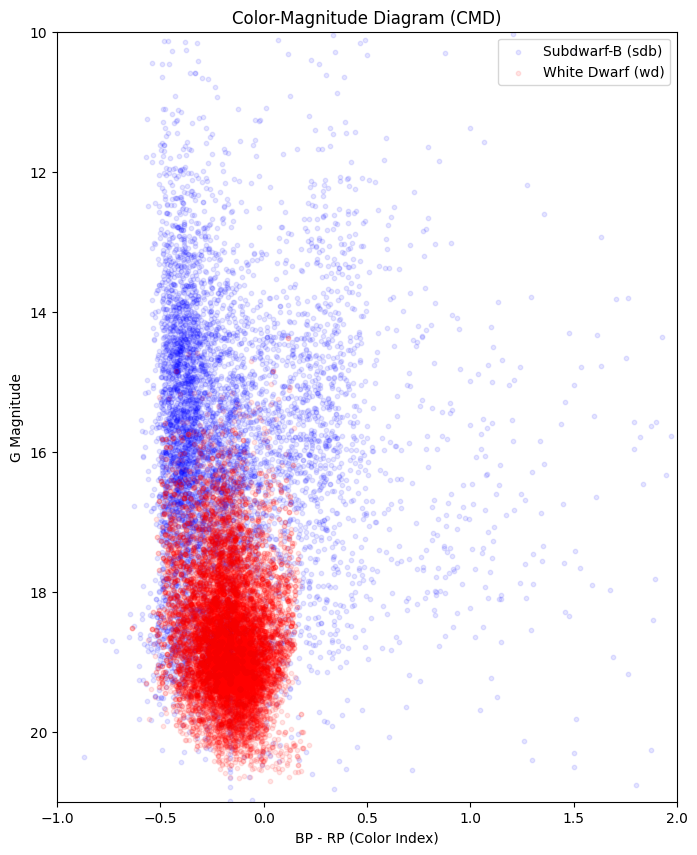

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Compute BP-RP color index
df['bp_rp'] = df['phot_bp_mean_mag'] - df['phot_rp_mean_mag']

# Filter white dwarfs and subdwarfs
df_wd = df[df['class'] == 'wd']
df_sdb = df[df['class'] == 'sdb']

# Create CMD plot
plt.figure(figsize=(8, 10))
plt.scatter(df_sdb['bp_rp'], df_sdb['phot_g_mean_mag'], c='blue', alpha=0.1, label='Subdwarf-B (sdb)', s=10)
plt.scatter(df_wd['bp_rp'], df_wd['phot_g_mean_mag'], c='red', alpha=0.1, label='White Dwarf (wd)', s=10)

# Set axis limits
plt.xlim(-1, 2)  # BP-RP color index range
plt.ylim(10, 21)   # G magnitude range (inverted for brightness)

# Invert y-axis (brighter stars at the top)
plt.gca().invert_yaxis()

# Labels and title
plt.xlabel("BP - RP (Color Index)")
plt.ylabel("G Magnitude")
plt.title("Color-Magnitude Diagram (CMD)")

# Show legend
plt.legend()

# Show plot
plt.show()

**Part 8.b: Plotting the results in a magnitude to parallax diagram** <br>
Here, we plot the magnitude against the parallax. Again, we should expect a cluster of blue dots located at the top left of a cluster of red dots.

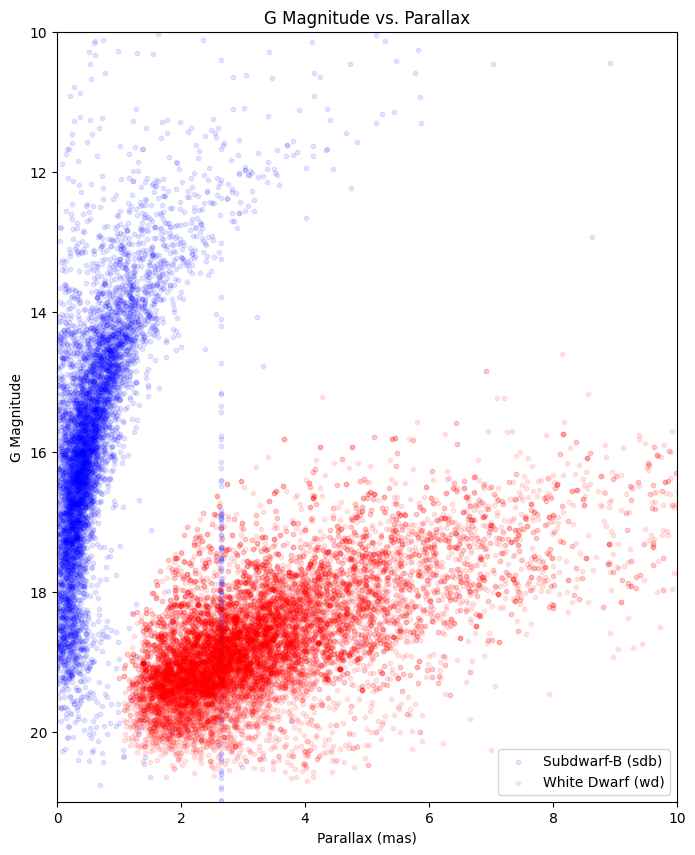

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Filter white dwarfs and subdwarfs
df_wd = df[df['class'] == 'wd']
df_sdb = df[df['class'] == 'sdb']

# Create the plot
plt.figure(figsize=(8, 10))
plt.scatter(df_sdb['parallax'], df_sdb['phot_g_mean_mag'], c='blue', alpha=0.1, label='Subdwarf-B (sdb)', s=10)
plt.scatter(df_wd['parallax'], df_wd['phot_g_mean_mag'], c='red', alpha=0.1, label='White Dwarf (wd)', s=10)

# Set axis limits (you may adjust based on your data distribution)
plt.xlim(0, 10)  # Ensure all positive parallax values are shown
plt.ylim(10, 21)  # Inverted y-axis for magnitude

# Invert y-axis (brighter stars at the top)
plt.gca().invert_yaxis()

# Labels and title
plt.xlabel("Parallax (mas)")  # Parallax is usually in milliarcseconds
plt.ylabel("G Magnitude")
plt.title("G Magnitude vs. Parallax")

# Show legend
plt.legend()

# Show plot
plt.show()

**Part 8.c: Adressing the blue vertical line by dropping the stars with faulty values** <br>
In the previous plot, we can see a blue vertical line. This is due to missing or invalid data being replaced by the mean average value of each feature. Dropping rows with faulty values should get rid of this blue vertical line.

In [ ]:
import pandas as pd

# Reread the dataset
df = pd.read_csv('dataset.csv')

# Select only the specified columns
selected_columns = ['source_id', 'phot_rp_mean_mag', 'phot_bp_mean_mag', 'phot_g_mean_mag', 'parallax', 'class']
df = df[selected_columns]

# Count elements with missing or invalid data in specified features
missing_data_count = df[
    df[['phot_rp_mean_mag', 'phot_bp_mean_mag', 'phot_g_mean_mag', 'parallax']].isnull().any(axis=1)
].shape[0]

print(f"Number of elements with missing or invalid data in 'phot_rp_mean_mag', 'phot_bp_mean_mag', 'phot_g_mean_mag', or 'parallax': {missing_data_count}")

# Count elements with missing data and 'wd' class
wd_missing_data_count = df[
    (df[['phot_rp_mean_mag', 'phot_bp_mean_mag', 'phot_g_mean_mag', 'parallax']].isnull().any(axis=1)) &
    (df['class'] == 'wd')
].shape[0]

print(f"Number of elements with missing data and 'wd' class: {wd_missing_data_count}")

# Count elements with missing data and 'sdb' class
sdb_missing_data_count = df[
    (df[['phot_rp_mean_mag', 'phot_bp_mean_mag', 'phot_g_mean_mag', 'parallax']].isnull().any(axis=1)) &
    (df['class'] == 'sdb')
].shape[0]

print(f"Number of elements with missing data and 'sdb' class: {sdb_missing_data_count}")


Number of elements with missing or invalid data in 'phot_rp_mean_mag', 'phot_bp_mean_mag', 'phot_g_mean_mag', or 'parallax': 171
Number of elements with missing data and 'wd' class: 0
Number of elements with missing data and 'sdb' class: 171


In [ ]:
# Drop rows with any missing or invalid values in specified columns
df = df.dropna(subset=['phot_rp_mean_mag', 'phot_bp_mean_mag', 'phot_g_mean_mag', 'parallax'])

# Count remaining elements with 'wd' and 'sdb' classes
wd_count = df[df['class'] == 'wd'].shape[0]
sdb_count = df[df['class'] == 'sdb'].shape[0]

print(f"Number of elements remaining with 'wd' class: {wd_count}")
print(f"Number of elements remaining with 'sdb' class: {sdb_count}")


Number of elements remaining with 'wd' class: 13857
Number of elements remaining with 'sdb' class: 6422


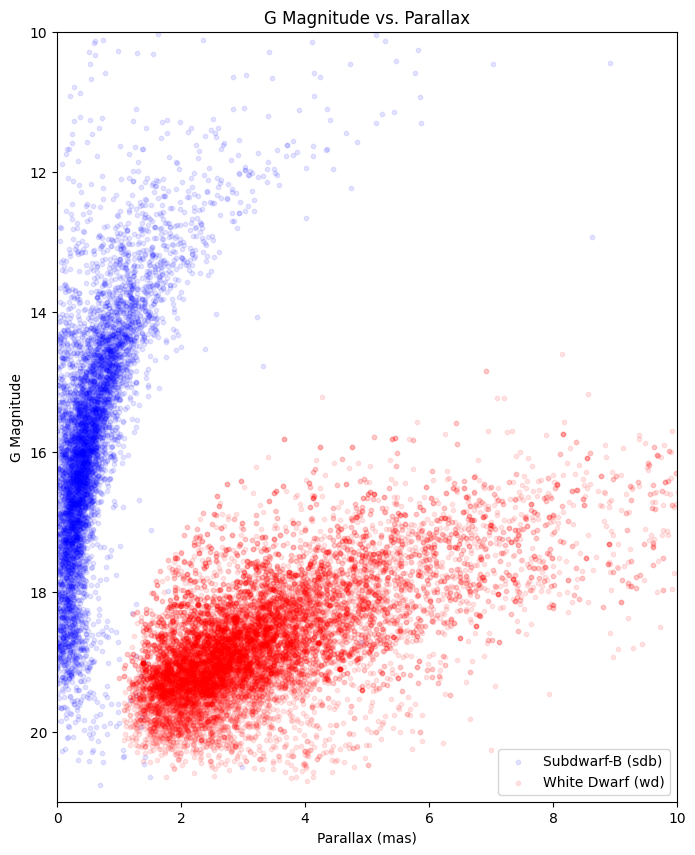

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Filter white dwarfs and subdwarfs
df_wd = df[df['class'] == 'wd']
df_sdb = df[df['class'] == 'sdb']

# Create the plot
plt.figure(figsize=(8, 10))
plt.scatter(df_sdb['parallax'], df_sdb['phot_g_mean_mag'], c='blue', alpha=0.1, label='Subdwarf-B (sdb)', s=10)
plt.scatter(df_wd['parallax'], df_wd['phot_g_mean_mag'], c='red', alpha=0.1, label='White Dwarf (wd)', s=10)

# Set axis limits (you may adjust based on your data distribution)
plt.xlim(0, 10)  # Ensure all positive parallax values are shown
plt.ylim(10, 21)  # Inverted y-axis for magnitude

# Invert y-axis (brighter stars at the top)
plt.gca().invert_yaxis()

# Labels and title
plt.xlabel("Parallax (mas)")  # Parallax is usually in milliarcseconds
plt.ylabel("G Magnitude")
plt.title("G Magnitude vs. Parallax")

# Show legend
plt.legend()

# Show plot
plt.show()

In [ ]:
# Filter the dataset to include only 'wd' and 'sdb' classes
df_filtered = df[df['class'].isin(['wd', 'sdb'])]

# Separate features (X) and target variable (y)
X = df_filtered[['phot_rp_mean_mag', 'phot_bp_mean_mag', 'phot_g_mean_mag', 'parallax']]
y = df_filtered['class']

# Convert target variable to numerical values (0 for 'wd', 1 for 'sdb')
y = y.map({'wd': 0, 'sdb': 1})

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Create a neural network model
model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2, verbose=0) # Suppress training output

# Evaluate the model on the test set
loss, accuracy = model.evaluate(X_test, y_test, verbose=0) # Suppress evaluation output
print('Test accuracy:', accuracy)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Test accuracy: 0.9995068907737732


# Part 9: Using the neural network on a new dataset
We will now try to use our neural network model and apply it on the new dataset.

**Part 9.a: Downloading the dataset and dropping all unnecessary features**<br>
We will use our knowledge gathered from the last dataset to directly drop all unnecessary features for our classification

In [ ]:
import pandas as pd
!wget --no-check-certificate 'https://drive.google.com/uc?export=download&id=1iV2rFZK9OJZWqzO2I9SP2PgQhlZWC1eE' -O dataset.csv
df2 = pd.read_csv('dataset.csv')
df2.shape


--2025-06-16 08:29:06--  https://drive.google.com/uc?export=download&id=1iV2rFZK9OJZWqzO2I9SP2PgQhlZWC1eE
Resolving drive.google.com (drive.google.com)... 142.250.141.100, 142.250.141.113, 142.250.141.102, ...
Connecting to drive.google.com (drive.google.com)|142.250.141.100|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1iV2rFZK9OJZWqzO2I9SP2PgQhlZWC1eE&export=download [following]
--2025-06-16 08:29:07--  https://drive.usercontent.google.com/download?id=1iV2rFZK9OJZWqzO2I9SP2PgQhlZWC1eE&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 142.250.141.132, 2607:f8b0:4023:c0b::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|142.250.141.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 66725130 (64M) [application/octet-stream]
Saving to: ‘dataset.csv’

dataset.csv         100%[===================>]  63.63M  46.2M

(61585, 153)

In [ ]:
# Keep only the specified columns in df2
df2 = df2[['source_id', 'phot_rp_mean_mag', 'phot_bp_mean_mag', 'phot_g_mean_mag', 'parallax']]

# Print the head of the new dataframe
print(df2.head())


             source_id  phot_rp_mean_mag  phot_bp_mean_mag  phot_g_mean_mag  \
0   604474251290699776         14.859774         14.465498        14.597474   
1   619153556155078272         14.664076         14.692213        14.705356   
2   614650192750888320         16.526846         17.007193        16.964804   
3  1978338700510656256         12.696702         12.412711        12.511989   
4  5624975872798794752         16.769178         16.724384        16.747410   

   parallax  
0  0.861644  
1  1.142478  
2  0.752423  
3  1.745146  
4  0.470509  


**Part 9.b: Plotting the stars in a magnitude vs parallax diagram**<br>
Here we plot our stars to see what we will be working with

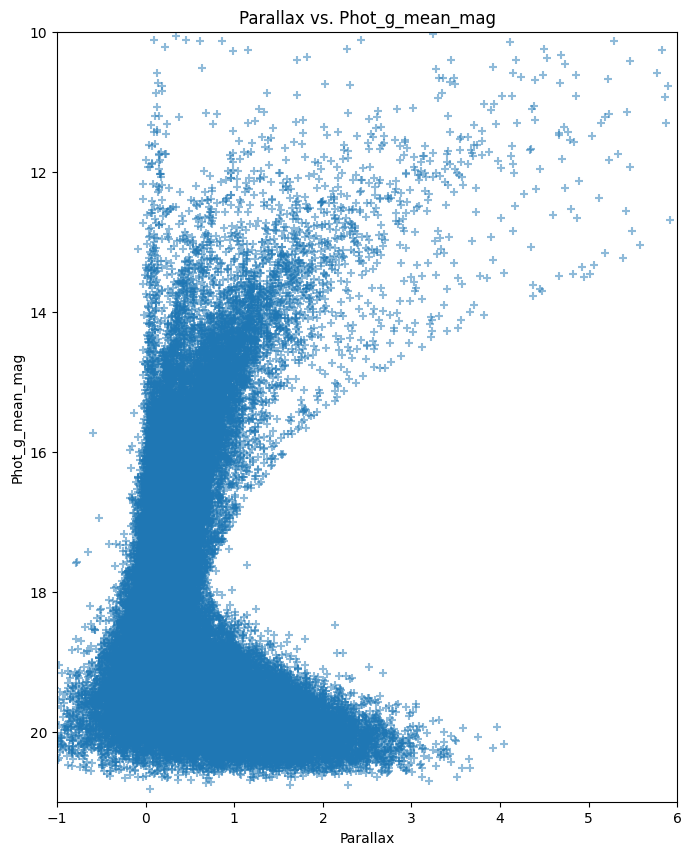

In [ ]:
import matplotlib.pyplot as plt

# Create the plot
plt.figure(figsize=(8, 10))
plt.scatter(df2['parallax'], df2['phot_g_mean_mag'], marker='+', alpha=0.5)

# Set axis limits
plt.xlim(-1, 6)
plt.ylim(10, 21)

# Invert the y-axis
plt.gca().invert_yaxis()

# Labels and title
plt.xlabel("Parallax")
plt.ylabel("Phot_g_mean_mag")
plt.title("Parallax vs. Phot_g_mean_mag")

# Show the plot
plt.show()


**Part 9.c: Using the neural network to classify the stars (with uncertainty threshold)**<br>
We first start by assigning the 'class' feature to the new dataframe, and assign each value of that feature as 'NaN'.<br>
Then, we use our neural network model created in Part 8 to classify the stars, but we use an uncertainty factor to it: If the neural network is unsure about the classification of a star, it classifies it as 'nc', for 'not classified'.

In [ ]:
# Add the 'class' feature to df2 with NaN values
df2['class'] = float('NaN')

# Print the head of the updated dataframe
print(df2.head())


             source_id  phot_rp_mean_mag  phot_bp_mean_mag  phot_g_mean_mag  \
0   604474251290699776         14.859774         14.465498        14.597474   
1   619153556155078272         14.664076         14.692213        14.705356   
2   614650192750888320         16.526846         17.007193        16.964804   
3  1978338700510656256         12.696702         12.412711        12.511989   
4  5624975872798794752         16.769178         16.724384        16.747410   

   parallax  class  
0  0.861644    NaN  
1  1.142478    NaN  
2  0.752423    NaN  
3  1.745146    NaN  
4  0.470509    NaN  


In [ ]:
import pandas as pd
import numpy as np

# Add the 'class' feature to df2 with NaN values
df2['class'] = float('NaN')

# Prepare df2 for prediction
df2_prepared = df2[['phot_rp_mean_mag', 'phot_bp_mean_mag', 'phot_g_mean_mag', 'parallax']].copy()

# Convert to numeric and handle missing values
for col in df2_prepared.columns:
    df2_prepared[col] = pd.to_numeric(df2_prepared[col], errors='coerce')
    df2_prepared[col].fillna(df2_prepared[col].mean(), inplace=True)

# Scale the features using the same scaler fitted on the training data
df2_scaled = scaler.transform(df2_prepared)

# Make predictions
predictions = model.predict(df2_scaled)

# Define the threshold for "uncertain" predictions
lower_threshold = 0.4
upper_threshold = 0.6

# Assign classifications
predicted_classes = []
for pred in predictions:
    if pred < lower_threshold:
        predicted_classes.append('wd')  # White Dwarf
    elif pred > upper_threshold:
        predicted_classes.append('sdb')  # Subdwarf-B
    else:
        predicted_classes.append('nc')  # Not Classified (uncertain)

# Replace the 'class' column in df2 with the predicted values
df2['class'] = predicted_classes

# Print the head of the updated DataFrame
print(df2.head())

# Count elements with 'wd', 'sdb', and 'nc' classes in df2
wd_count = df2[df2['class'] == 'wd'].shape[0]
sdb_count = df2[df2['class'] == 'sdb'].shape[0]
nc_count = df2[df2['class'] == 'nc'].shape[0]

print(f"Number of elements with 'wd' class in df2: {wd_count}")
print(f"Number of elements with 'sdb' class in df2: {sdb_count}")
print(f"Number of elements with 'nc' class in df2: {nc_count}")

  53/1925 ━━━━━━━━━━━━━━━━━━━━ 1s 978us/step 

<ipython-input-25-286117709>:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df2_prepared[col].fillna(df2_prepared[col].mean(), inplace=True)


1925/1925 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
             source_id  phot_rp_mean_mag  phot_bp_mean_mag  phot_g_mean_mag  \
0   604474251290699776         14.859774         14.465498        14.597474   
1   619153556155078272         14.664076         14.692213        14.705356   
2   614650192750888320         16.526846         17.007193        16.964804   
3  1978338700510656256         12.696702         12.412711        12.511989   
4  5624975872798794752         16.769178         16.724384        16.747410   

   parallax class  
0  0.861644   sdb  
1  1.142478   sdb  
2  0.752423   sdb  
3  1.745146   sdb  
4  0.470509   sdb  
Number of elements with 'wd' class in df2: 7870
Number of elements with 'sdb' class in df2: 52936
Number of elements with 'nc' class in df2: 779


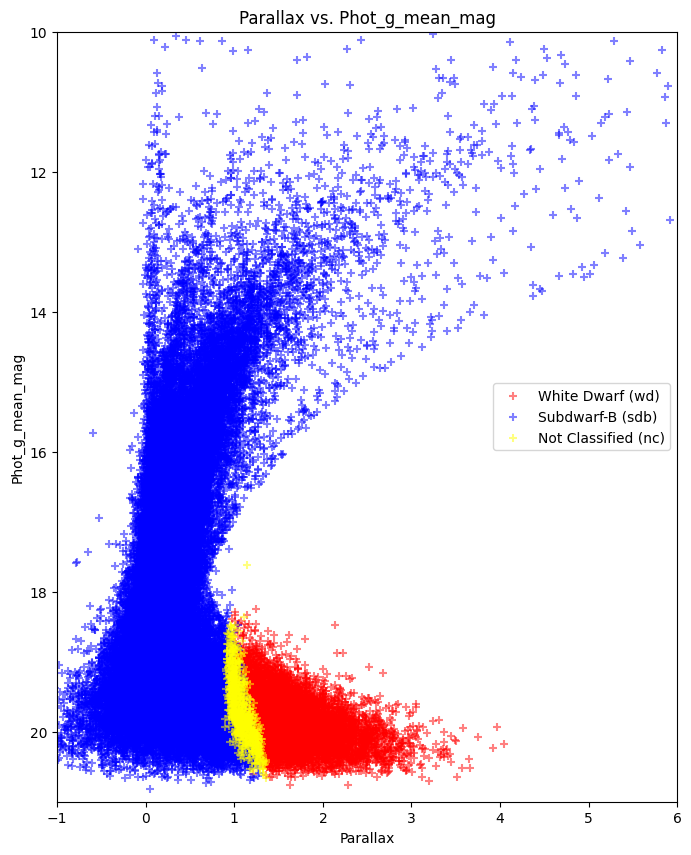

In [ ]:
import matplotlib.pyplot as plt
# Create the plot
plt.figure(figsize=(8, 10))

# Color elements based on 'class'
plt.scatter(df2[df2['class'] == 'wd']['parallax'], df2[df2['class'] == 'wd']['phot_g_mean_mag'], c='red', marker='+', alpha=0.5, label='White Dwarf (wd)')
plt.scatter(df2[df2['class'] == 'sdb']['parallax'], df2[df2['class'] == 'sdb']['phot_g_mean_mag'], c='blue', marker='+', alpha=0.5, label='Subdwarf-B (sdb)')
plt.scatter(df2[df2['class'] == 'nc']['parallax'], df2[df2['class'] == 'nc']['phot_g_mean_mag'], c='yellow', marker='+', alpha=0.5, label='Not Classified (nc)')

# Set axis limits
plt.xlim(-1, 6)
plt.ylim(10, 21)

# Invert the y-axis
plt.gca().invert_yaxis()

# Labels and title
plt.xlabel("Parallax")
plt.ylabel("Phot_g_mean_mag")
plt.title("Parallax vs. Phot_g_mean_mag")
plt.legend()
# Show the plot
plt.show()

In [ ]:
import pandas as pd
from google.colab import files

# Create a list to store the lines for the text file
file_lines = []

# Iterate through the 'nc' stars in df2
for index, row in df2[df2['class'] == 'nc'].iterrows():
    rank = index + 1  # Calculate the rank
    source_id = row['source_id']
    prediction = predictions[index][0]  # Access the prediction value
    classification = 'wd' if prediction < 0.5 else 'sdb' # Determine the classification
    file_lines.append(f"{rank} {source_id} {prediction:.4f} {classification}") #format the output

# Create the text file
with open('nc_stars.txt', 'w') as f:
  f.write('\n'.join(file_lines))

# Download the file
files.download('nc_stars.txt')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Part 9.d: Reclassifying stars with negative parallax**<br>
Now we can classify stars with negative parallax. We'll color them as purple plus symbols.<br>

In [ ]:
# Change the 'class' value for elements with negative parallax
df2.loc[df2['parallax'] < 0, 'class'] = 'np'

# Print the head to verify
print(df2.head())


             source_id  phot_rp_mean_mag  phot_bp_mean_mag  phot_g_mean_mag  \
0   604474251290699776         14.859774         14.465498        14.597474   
1   619153556155078272         14.664076         14.692213        14.705356   
2   614650192750888320         16.526846         17.007193        16.964804   
3  1978338700510656256         12.696702         12.412711        12.511989   
4  5624975872798794752         16.769178         16.724384        16.747410   

   parallax class  
0  0.861644   sdb  
1  1.142478   sdb  
2  0.752423   sdb  
3  1.745146   sdb  
4  0.470509   sdb  


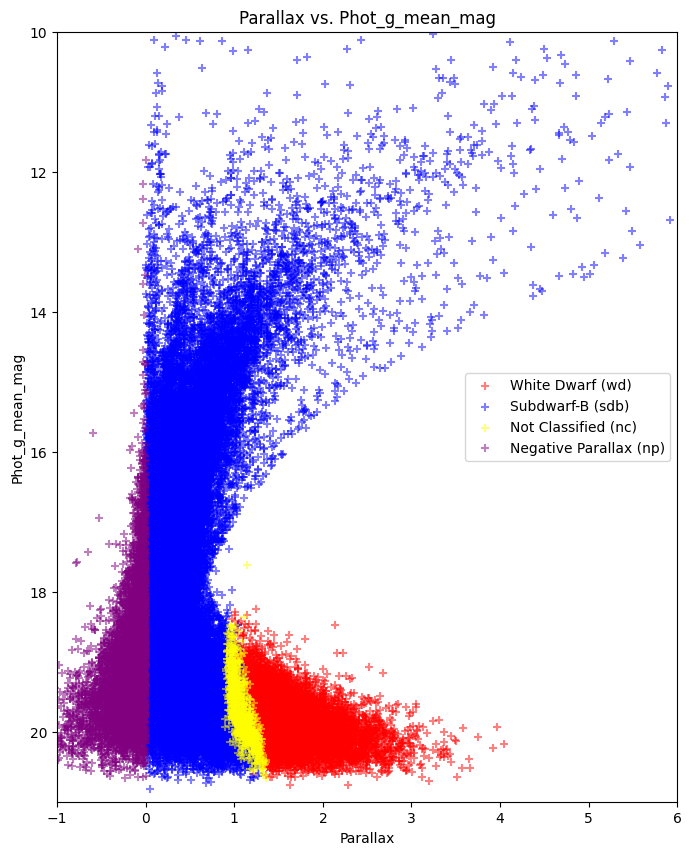

In [ ]:
import matplotlib.pyplot as plt

# Create the plot
plt.figure(figsize=(8, 10))

# Color elements based on 'class'
plt.scatter(df2[df2['class'] == 'wd']['parallax'], df2[df2['class'] == 'wd']['phot_g_mean_mag'], c='red', marker='+', alpha=0.5, label='White Dwarf (wd)')
plt.scatter(df2[df2['class'] == 'sdb']['parallax'], df2[df2['class'] == 'sdb']['phot_g_mean_mag'], c='blue', marker='+', alpha=0.5, label='Subdwarf-B (sdb)')
plt.scatter(df2[df2['class'] == 'nc']['parallax'], df2[df2['class'] == 'nc']['phot_g_mean_mag'], c='yellow', marker='+', alpha=0.5, label='Not Classified (nc)')
plt.scatter(df2[df2['class'] == 'np']['parallax'], df2[df2['class'] == 'np']['phot_g_mean_mag'], c='purple', marker='+', alpha=0.5, label='Negative Parallax (np)')

# Set axis limits
plt.xlim(-1, 6)
plt.ylim(10, 21)

# Invert the y-axis
plt.gca().invert_yaxis()

# Labels and title
plt.xlabel("Parallax")
plt.ylabel("Phot_g_mean_mag")
plt.title("Parallax vs. Phot_g_mean_mag")
plt.legend()

# Show the plot
plt.show()